### Isolation forest is one the more advanced outlier detection/removal algorithms

Unlike IQR and Z-score -approaches, Isolation Forest is actually a machine learning algorithm, which will also remove outliers and (and partially noise) within the distribution itself.

In [1]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.005) 
df = pd.read_csv("../houses.csv")

# REMEMBER! Isolation Forest is a machine learning algorithm
# => ALL VARIABLES HAVE TO BE NUMERIC AT THIS POINT

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

Inliers: 21504
Outliers: 109


#### It's usually easier to see if we removed enough or too much by visualizing!

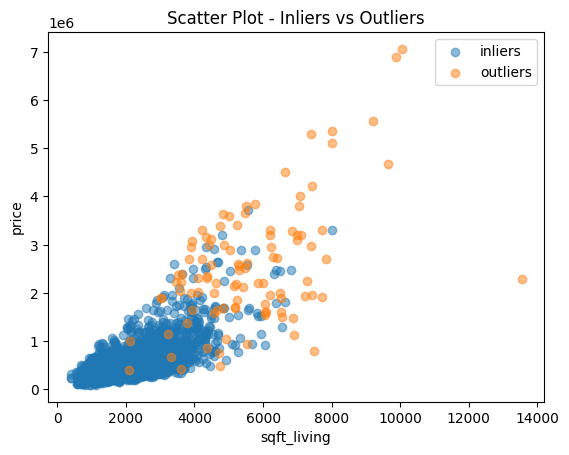

In [2]:
import matplotlib.pyplot as plt

# change the variable if you want to inspect this from other point of views
variable = "sqft_living"
target = "price"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(3000)
outliers_sample = outliers.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [3]:
outliers

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
246,2400000.0,4,2.50,3650,8354,1.0,1,4,3,9,1830,1820,2000,0,3120,18841
269,2900000.0,4,3.25,5050,20100,1.5,0,2,3,11,4750,300,1982,2008,3890,20060
300,3075000.0,4,5.00,4550,18641,1.0,1,4,3,10,2600,1950,2002,0,4550,19508
419,1550000.0,5,4.25,6070,171626,2.0,0,0,3,12,6070,0,1999,0,4680,211267
527,1600000.0,6,5.00,6050,230652,2.0,0,3,3,11,6050,0,2001,0,4210,233971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20452,1600000.0,4,5.50,6530,871200,2.0,0,2,3,11,6530,0,2008,0,1280,858132
20767,2300000.0,4,4.00,4360,8175,2.5,1,4,3,10,3940,420,2007,0,2670,8525
21344,1488000.0,5,6.00,6880,279968,2.0,0,3,3,12,4070,2810,2007,0,4690,256803
21506,2238890.0,5,6.50,7270,130017,2.0,0,0,3,12,6420,850,2010,0,1800,44890


### Another popular alternative: Elliptic Envelope

In [4]:
from sklearn.covariance import EllipticEnvelope

# contamination, same thing as in isolation
ee = EllipticEnvelope(contamination=0.005)
df = pd.read_csv("../houses.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)
y_pred = ee.fit_predict(df)
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]


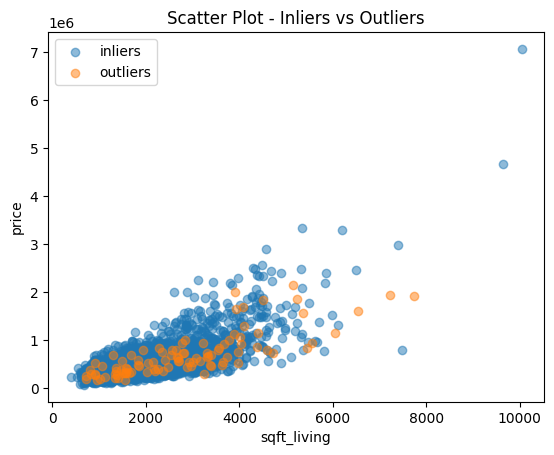

In [5]:
import matplotlib.pyplot as plt

variable = "sqft_living"
target = "price"

# if you want to reduce the number of points visualized
# sample a small amount of points, for example 300-500
inliers_sample = inliers.sample(3000)
outliers_sample = outliers.sample(100)

plt.scatter(inliers_sample[variable], inliers_sample[target], label="inliers", alpha=0.5)
plt.scatter(outliers_sample[variable], outliers_sample[target], label="outliers", alpha=0.5)

plt.xlabel(variable)
plt.ylabel(target)

plt.title("Scatter Plot - Inliers vs Outliers")
plt.legend()
plt.show()

In [6]:
outliers

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
145,921500.0,4,2.50,3670,315374,2.0,0,0,4,9,3670,0,1994,0,2840,87991
380,270000.0,2,1.50,1380,209959,1.0,0,0,1,6,1380,0,1954,0,3130,19868
929,390000.0,4,3.00,2570,262018,1.0,0,0,3,7,1420,1150,1988,0,2260,19811
1255,600000.0,2,2.50,2410,102366,1.0,0,0,4,7,1940,470,1912,1989,2460,310582
1719,700000.0,4,1.00,1300,1651359,1.0,0,3,4,6,1300,0,1920,0,2560,425581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20499,760000.0,4,2.75,3980,285318,2.0,0,2,3,9,3980,0,2006,0,2100,105415
20811,580000.0,3,2.50,1820,374616,2.0,0,0,3,7,1820,0,1999,0,1870,220654
20920,1830000.0,4,4.25,4500,215186,2.0,0,3,3,11,2630,1870,2009,0,3030,25447
20974,950000.0,3,2.50,2780,275033,1.0,0,0,3,10,2780,0,2006,0,1680,16340
